In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

# 선형, 다항, 리지, 라쏘 회귀

1. 선형회귀 (Linear Regression)

** 정의 : 
독립변수(입력 데이터)와 종속변수(출력 데이터) 간의 직선 관계를 모델링. 
수학적 표현 : 𝑦=𝛽0+𝛽1𝑥+𝜖

** 특징 : 
데이터가 독립변수와 종속변수 사이에서 직선 관계에 가까울 때 효과적.
계산 속도가 빠르고 해석이 간단.
과적합(overfitting)의 위험이 적음.



<br>
<br>

2. 다항회귀 (Polynomial Regression)

** 정의 : 
독립변수와 종속변수 간의 비선형 관계를 모델링.
다항식 형태의 모델을 사용하여 데이터의 곡선 패턴을 표현 : y=β0​+β1​x+β2​x2+⋯+βn​xn+ϵ ,… 같은 다항식 항들이 추가

** 특징 : 
데이터가 곡선 형태의 관계를 보일 때 적합.
차수(degree)를 높일수록 데이터의 패턴을 더 잘 학습할 수 있지만, 과적합의 위험이 증가.
모델의 복잡도는 조정 가능.

** 적용 예시 : 초기엔 증가, 이후 감소하는 패턴 등, 
온도 변화와 에너지 소비량의 관계
자동차 속도와 연비의 관계

** 다항회귀는 데이터가 비선형적인 패턴을 보일 때, 이를 효과적으로 모델링하기 위해 독립변수를 고차항으로 변환.
PolynomialFeatures를 사용해 데이터를 변환한 후, 이를 선형회귀 모델에 학습시키는 방식으로 구현.
따라서, 다항회귀는 "데이터를 알아서 다차원으로 만드는" 것이 아니라, 사용자가 명시적으로 데이터를 다항식 특성으로 변환해야 하며, 변환된 데이터를 모델에 전달해 학습하게 됨.

** 다항회귀에서는 **원래 데이터(독립변수)**를 기반으로 추가적인 차원을 생성. 이를 통해 입력 데이터를 **다항식 특성(polynomial features)**으로 변환하여 비선형 관계를 학습할 수 있게 함. 하지만, 이 변환은 자동으로 수행되는 것이 아니라, 명시적으로 데이터를 변환해야 함.

<br>
<br>

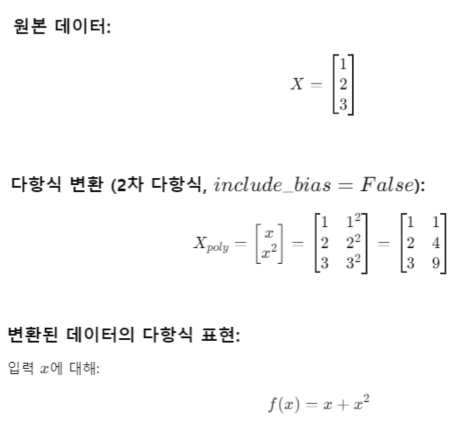

In [ ]:
# 다항식 변경 예
from sklearn.preprocessing import PolynomialFeatures

# 원본 데이터 (1차원을 2차원으로)
X = np.array([1, 2, 3]).reshape(-1, 1)  # 3행 1열의 2차원 배열, -1이면 프로그램에서 알아서 결정(3이 된다)

print("원본 데이터:")
print(X)

## 다항식 변환
poly = PolynomialFeatures(degree=3, include_bias=False)  ## 3차항으로 변환, 상수(절편)항은 포함하지 않음
X_poly = poly.fit_transform(X)

print("\n다항식 변환된 데이터:")
print(X_poly)

원본 데이터:
[[1]
 [2]
 [3]]

다항식 변환된 데이터:
[[ 1.  1.  1.]
 [ 2.  4.  8.]
 [ 3.  9. 27.]]


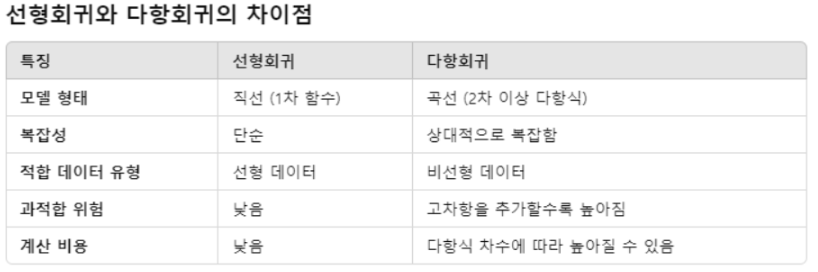

## 1. 선형회귀

선형 회귀 결정계수 (R^2): 0.3966


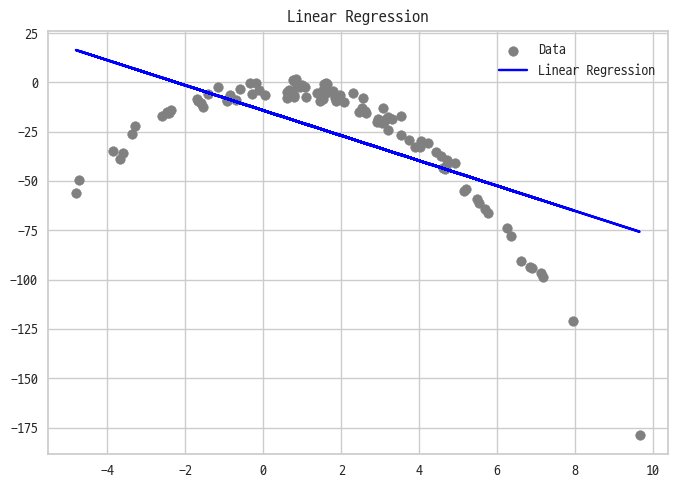

In [3]:
# 데이터 생성
np.random.seed(0)
X = 2 - 3 * np.random.normal(0, 1, 100).reshape(-1, 1)  
y = X - 2 * (X**2) + np.random.normal(-3, 3, 100).reshape(-1, 1)  # 2차원 배열로 변환

# 선형 회귀 모델 학습
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_lin = lin_reg.predict(X)

# 결정계수 (R^2)
r2_lin = lin_reg.score(X, y)  

# 출력
print(f"선형 회귀 결정계수 (R^2): {r2_lin:.4f}")

# 시각화
plt.scatter(X, y, color='gray', label='Data')
plt.plot(X, y_pred_lin, color='blue', label='Linear Regression')
plt.legend()
plt.title('Linear Regression')
plt.show()

In [4]:
# 새로운 데이터 예측
X_new = [[1.5]]  # 예: 입력값이 1.5일 때
y_new_pred = lin_reg.predict(X_new)

print(f"X = {X_new[0][0]} 일 때 선형 회귀 예측값: {y_new_pred[0][0]:.4f}")

X = 1.5 일 때 선형 회귀 예측값: -23.8066


In [ ]:
# 실제값과 비교시 차이가 나는 것을 확인할 수 있다

new_Xs = np.array([[0], [1], [2], [5]])
y_preds = lin_reg.predict(new_Xs)
for x_val, y_pred in zip(new_Xs.flatten(), y_preds):
    print(f"X = {x_val} 일 때 선형 회귀 예측값: {y_pred[0]:.4f}")

X = 0 일 때 선형 회귀 예측값: -14.2580
X = 1 일 때 선형 회귀 예측값: -20.6237
X = 2 일 때 선형 회귀 예측값: -26.9894
X = 5 일 때 선형 회귀 예측값: -46.0866


## 2. 다항회귀

선형 회귀 결정계수 (R^2): 0.3966
다항 회귀 결정계수 (R^2): 0.9899


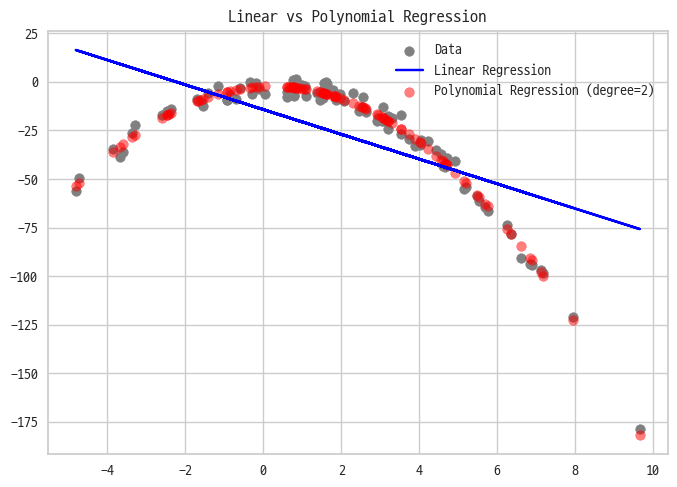

In [6]:
# 다항 변환 (2차 다항식)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# 표준화(반드시 필요)
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# 선형 회귀 모델 학습 (원본 데이터 사용)
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_lin = lin_reg.predict(X)

# 다항 회귀 모델 학습 (변환 데이터 사용)
poly_reg = LinearRegression()
poly_reg.fit(X_poly_scaled, y)
y_pred_poly = poly_reg.predict(X_poly_scaled)

# 결정계수 (R^2)
r2_lin = lin_reg.score(X, y)  # 선형 회귀
r2_poly = poly_reg.score(X_poly_scaled, y)  # 다항 회귀

# 출력
print(f"선형 회귀 결정계수 (R^2): {r2_lin:.4f}")
print(f"다항 회귀 결정계수 (R^2): {r2_poly:.4f}")

# 시각화
plt.scatter(X, y, color='gray', label='Data')
plt.plot(X, y_pred_lin, color='blue', label='Linear Regression')
plt.scatter(X, y_pred_poly, color='red', label='Polynomial Regression (degree=2)', alpha=0.5)
plt.legend()
plt.title('Linear vs Polynomial Regression')
plt.show()

In [7]:
# 새로운 입력값 (예: X=0.5)
X_new = np.array([[0.5]])

# 선형 회귀 예측
y_pred_lin_new = lin_reg.predict(X_new)

# 다항 회귀 예측
X_new_poly = poly_features.transform(X_new)
X_new_poly_scaled = scaler.transform(X_new_poly)
y_pred_poly_new = poly_reg.predict(X_new_poly_scaled)

# 출력
print(f"X={X_new[0][0]} 에 대한 선형 회귀 예측값: {y_pred_lin_new[0][0]:.4f}")
print(f"X={X_new[0][0]} 에 대한 다항 회귀 예측값: {y_pred_poly_new[0][0]:.4f}")

X=0.5 에 대한 선형 회귀 예측값: -17.4408
X=0.5 에 대한 다항 회귀 예측값: -2.4374


In [8]:
X_news = np.array([[0], [1], [2], [5]])

# 선형 회귀 예측
y_pred_lin_news = lin_reg.predict(X_news)

# 다항 변환 + 표준화 + 다항 회귀 예측
X_news_poly = poly_features.transform(X_news)
X_news_poly_scaled = scaler.transform(X_news_poly)
y_pred_poly_news = poly_reg.predict(X_news_poly_scaled)

# 결과 출력
for i, x_val in enumerate(X_news.flatten()):
    print(f"X={x_val}")
    print(f"  선형 회귀 예측값: {y_pred_lin_news[i][0]:.4f}")
    print(f"  다항 회귀 예측값: {y_pred_poly_news[i][0]:.4f}\n")

X=0
  선형 회귀 예측값: -14.2580
  다항 회귀 예측값: -2.4148

X=1
  선형 회귀 예측값: -20.6237
  다항 회귀 예측값: -3.4711

X=2
  선형 회귀 예측값: -26.9894
  다항 회귀 예측값: -8.5719

X=5
  선형 회귀 예측값: -46.0866
  다항 회귀 예측값: -48.1412



## 3. 리지회귀 (Ridge Regression)

* 회귀계수가 너무 커지는 것을 억제하여 과적합을 줄이는 선형 회귀
* 계수를 0에 가깝게 만들어 줌
* 표준화가 필수
* 곡선이 부드러워짐

In [ ]:
from sklearn.linear_model import Ridge

# 다항 변환 (2차 다항식)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# 데이터 표준화
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# 리지 회귀 모델 학습 (alpha 값을 크게 설정)
ridge_reg = Ridge(alpha=1.0)    # 1.0이 거의 표준
ridge_reg.fit(X_poly_scaled, y)
y_pred_ridge = ridge_reg.predict(X_poly_scaled)

# 결정계수(R²) 계산
r2 = ridge_reg.score(X_poly_scaled, y)
print(f"리지 회귀 모델의 결정계수 (R²): {r2:.4f}")

리지 회귀 모델의 결정계수 (R²): 0.9897


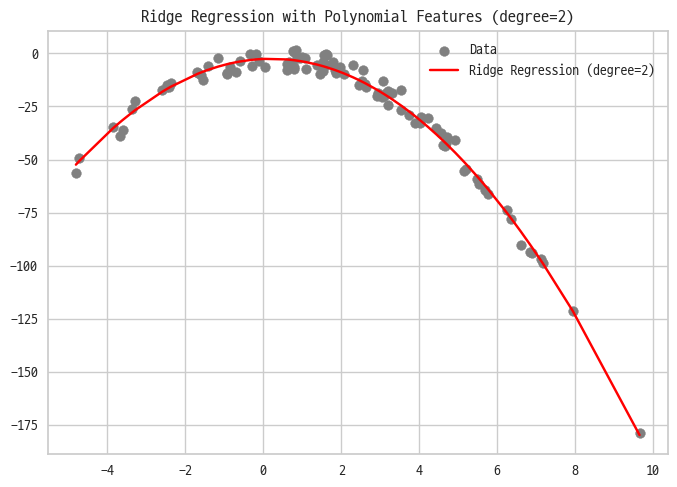

In [10]:
# 시각화
plt.scatter(X, y, color='gray', label='Data')

# 예측값에 대해 X 값을 정렬하여 그래프 그리기
X_sorted = np.sort(X, axis=0)  # X 값을 오름차순으로 정렬
X_sorted_poly = poly_features.transform(X_sorted)  # 다항 변환 적용
X_sorted_poly_scaled = scaler.transform(X_sorted_poly)  # 다항 특성 표준화
y_sorted_pred = ridge_reg.predict(X_sorted_poly_scaled)  # 예측값

# 정렬된 X 값에 대해 예측된 y 값을 선으로 연결
plt.plot(X_sorted, y_sorted_pred, color='red', label='Ridge Regression (degree=2)')

plt.legend()
plt.title('Ridge Regression with Polynomial Features (degree=2)')
plt.show()

In [11]:
# 예측할 새로운 값
new_X = np.array([[5]])

# 1. 다항 변환
new_X_poly = poly_features.transform(new_X)

# 2. 표준화
new_X_poly_scaled = scaler.transform(new_X_poly)

# 3. 예측
y_pred_new = ridge_reg.predict(new_X_poly_scaled)

print(f"X=5일 때 리지 다항 회귀 예측값: {y_pred_new.item():.2f}")

X=5일 때 리지 다항 회귀 예측값: -48.13


In [12]:
new_Xs = np.array([[0], [1], [2], [5]])
new_Xs_poly = poly_features.transform(new_Xs)
new_Xs_poly_scaled = scaler.transform(new_Xs_poly)
y_preds = ridge_reg.predict(new_Xs_poly_scaled)
for x_val, y_pred in zip(new_Xs.flatten(), y_preds):
    print(f"X={x_val} 일 때 리지 회귀 예측값: {y_pred.item():.4f}")

X=0 일 때 리지 회귀 예측값: -2.6307
X=1 일 때 리지 회귀 예측값: -3.7986
X=2 일 때 리지 회귀 예측값: -8.9322
X=5 일 때 리지 회귀 예측값: -48.1271


## 4. 라쏘회귀 (Lasso Regression)

* 불필요한 변수의 계수를 0으로 만들어 변수를 선택하여 수행하는 회귀 모델
* 중요하지 않은 변수 → 계수를 0으로 만들어 자동 제거
* 모델 단순화

In [13]:
from sklearn.linear_model import Lasso

# 다항 변환 (2차 다항식)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# 데이터 표준화 (PolynomialFeatures 후)
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)  # 다항 특성 표준화

# 라쏘 회귀 모델 학습 (alpha 값을 크게 설정)
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_poly_scaled, y)
y_pred_lasso = lasso_reg.predict(X_poly_scaled)

# 결정계수(R²) 계산 및 출력
r2 = lasso_reg.score(X_poly_scaled, y)
print(f"라쏘 회귀 모델의 결정계수 (R²): {r2:.4f}")

라쏘 회귀 모델의 결정계수 (R²): 0.9898


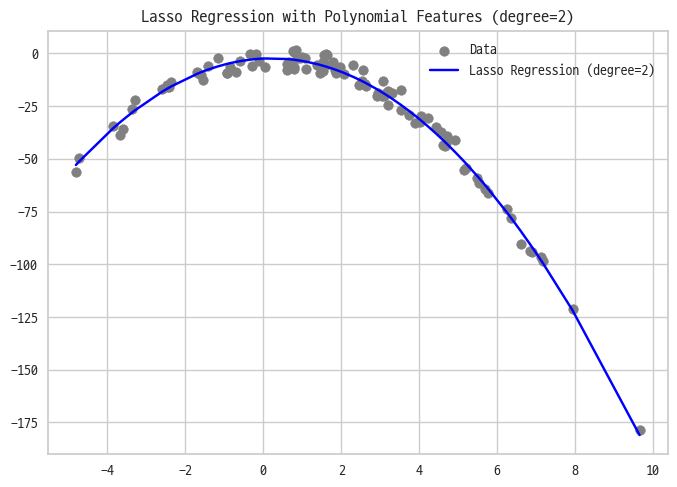

In [14]:
# 시각화
plt.scatter(X, y, color='gray', label='Data')

# 예측값에 대해 X 값을 정렬하여 그래프 그리기
X_sorted = np.sort(X, axis=0)  # X 값을 오름차순으로 정렬
X_sorted_poly = poly_features.transform(X_sorted)  # 다항 변환 적용
X_sorted_poly_scaled = scaler.transform(X_sorted_poly)  # 다항 특성 표준화
y_sorted_pred = lasso_reg.predict(X_sorted_poly_scaled)  # 예측값

# 정렬된 X 값에 대해 예측된 y 값을 선으로 연결
plt.plot(X_sorted, y_sorted_pred, color='blue', label='Lasso Regression (degree=2)')

plt.legend()
plt.title('Lasso Regression with Polynomial Features (degree=2)')
plt.show()